In [45]:
#import the necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import matplotlib.ticker as ticker
import warnings

In [46]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [47]:
df.describe()


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [48]:
#sort formats for all dates 
df.drop('Row ID',axis = 1, inplace = True) #Dropping the Row ID column
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y') #convert Order dates to pandas datetime format
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')   #convert shipping dates to pandas datetime format
df['Month_order'] = df['Order Date'].dt.to_period('M')
df['Year_order'] = df['Order Date'].dt.to_period('Y')

In [49]:
#sorting data by order date
df.sort_values(by=['Order Date'], inplace=True, ascending=True)

In [50]:
#setting the index to be the date
df.set_index("Order Date", inplace = True)

In [51]:
#check null vals 
print(df.isnull().sum())

Order ID          0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Month_order       0
Year_order        0
dtype: int64


In [52]:
df[df['Postal Code'].isnull()]


,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month_order,Year_order
Order Date,,,,,,,,,,,,,,,,,,
2016-11-07,CA-2016-162887,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,2016-11,2016
2016-11-08,CA-2016-117086,2016-11-12,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4404.90,2016-11,2016
2017-01-23,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2017-01,2017
2017-01-23,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,2017-01,2017
2017-01-23,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,2017-01,2017
2017-04-06,US-2017-150140,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,2017-04,2017
2018-01-19,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,2018-01,2018
2018-01-19,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,2018-01,2018
2018-01-19,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,2018-01,2018


In [53]:
df['Postal Code'] = df['Postal Code'].fillna(5401) #postal code for burlington city bc all records of burlington city has missing postal 

In [54]:
#check again
print(df.isnull().sum())


Order ID         0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Month_order      0
Year_order       0
dtype: int64


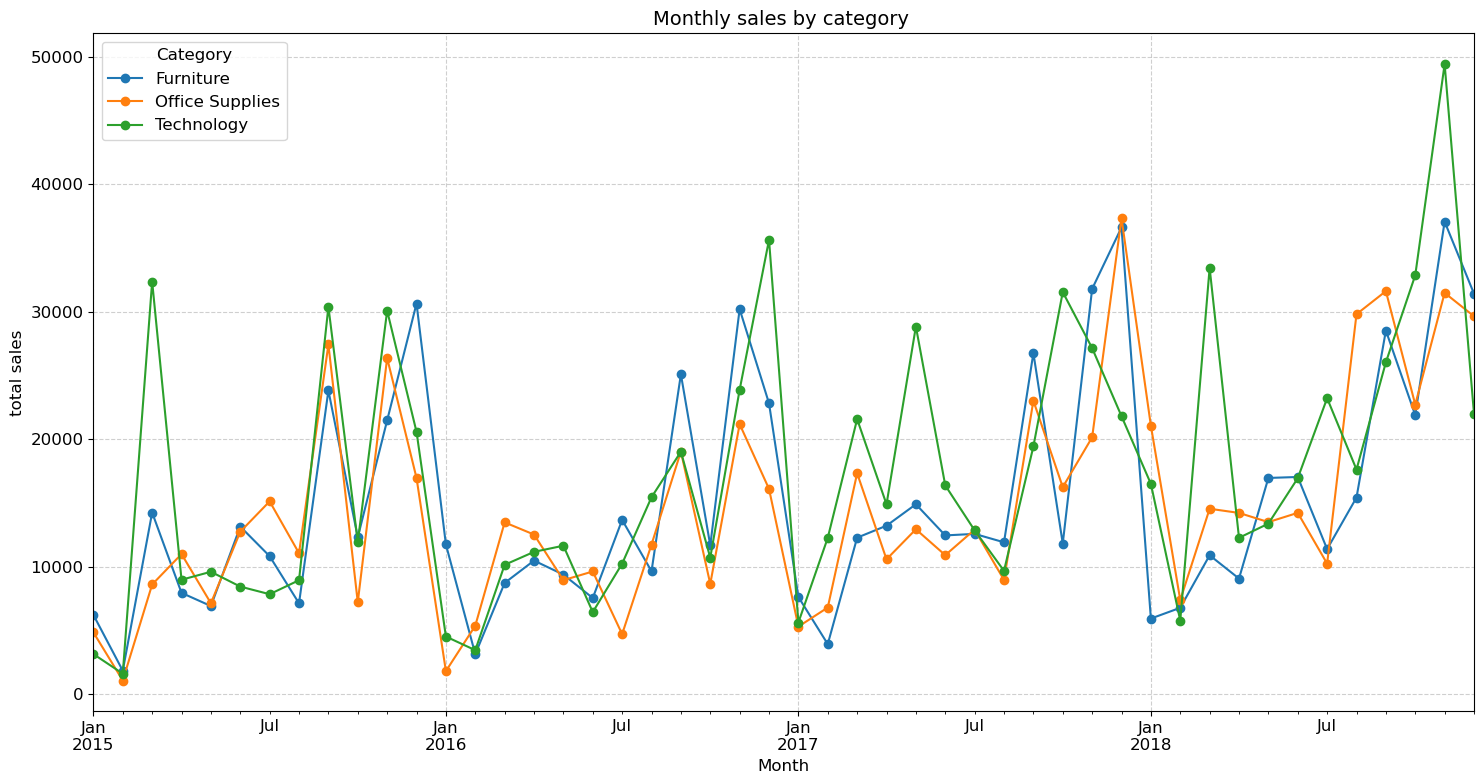

In [55]:
# month sales analysis
monthSalesByCategory = df.groupby(["Month_order", "Category"])["Sales"].sum().unstack()


monthSalesByCategory.plot(kind="line", marker="o", figsize=(15, 8))
plt.title("Monthly sales by category ", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("total sales", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Category", fontsize=12)
plt.tight_layout()

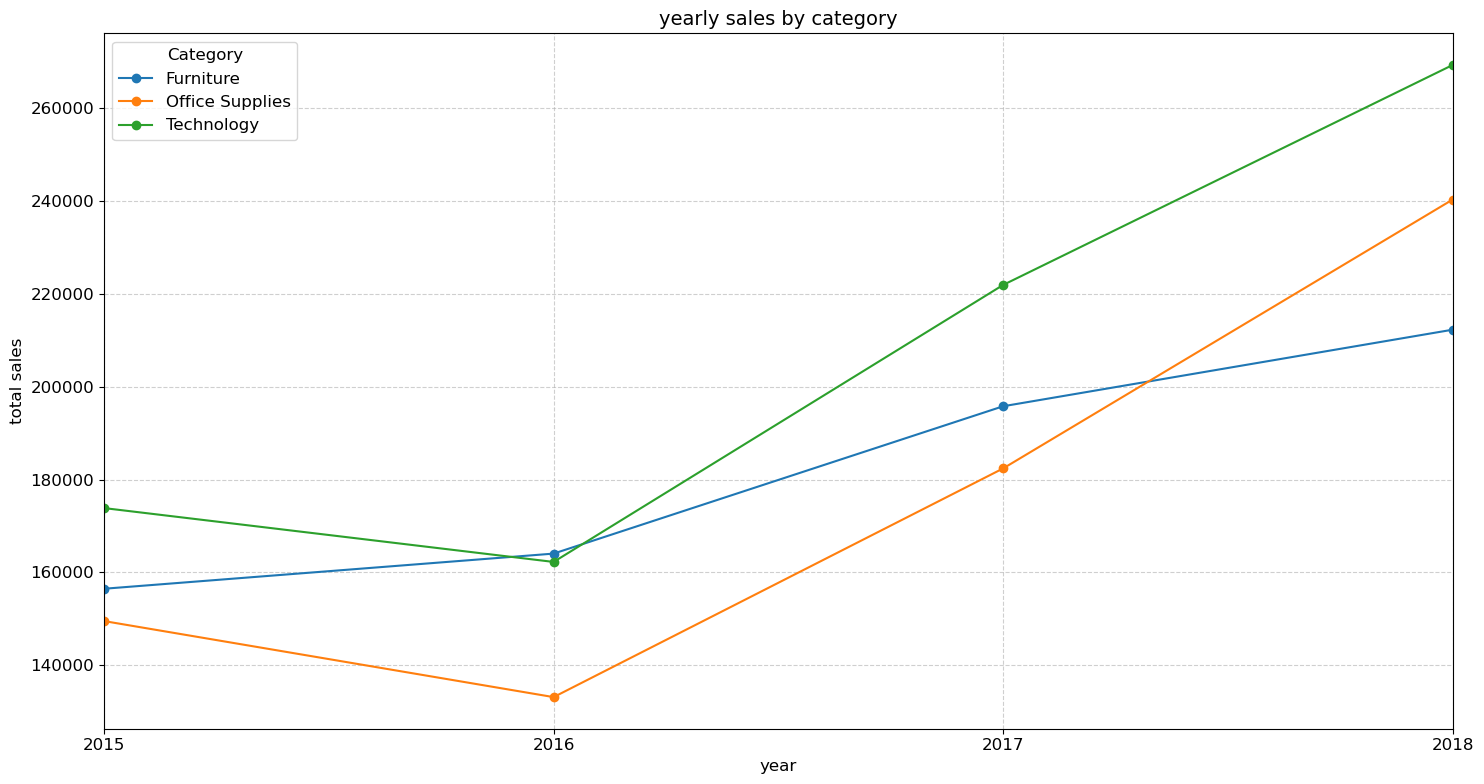

In [56]:
# 4 year sales analysis
yearlyOrder = df.groupby(["Year_order", "Category"])["Sales"].sum().unstack()

yearlyOrder.plot(kind="line", marker="o", figsize=(15, 8))
plt.title("yearly sales by category", fontsize=14)
plt.xlabel("year", fontsize=12)
plt.ylabel("total sales", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Category", fontsize=12)
plt.tight_layout()

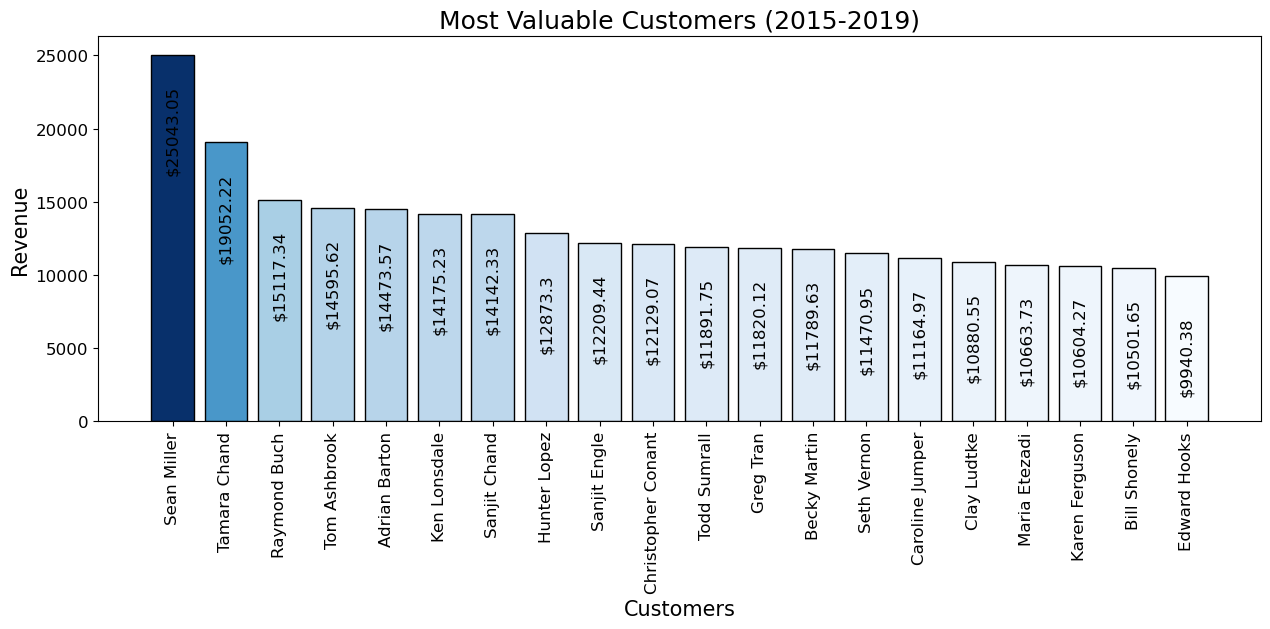

In [57]:
# distribution of most valuable customers
Top_customers = df.groupby(["Customer Name"])["Sales"].sum().sort_values(ascending=False).head(20)

Top_customers = Top_customers.round(2)  # Round off the Sales Value up to 2 decimal places
Top_customers = Top_customers.reset_index()  # Reset index to move "Customer Name" back as a column

plt.figure(figsize=(15,5))  # Width and height of figure
plt.title("Most Valuable Customers (2015-2019)", fontsize=18)

# Normalize sales values for color mapping
norm = plt.Normalize(Top_customers["Sales"].min(), Top_customers["Sales"].max())
colors = plt.cm.Blues(norm(Top_customers["Sales"]))  # Using a purple gradient

plt.bar(Top_customers["Customer Name"], Top_customers["Sales"], color=colors, edgecolor='black', linewidth=1)
plt.xlabel("Customers", fontsize=15)  # X-axis label
plt.ylabel("Revenue", fontsize=15)  # Y-axis label
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)

# Add text labels
for k, v in zip(Top_customers["Customer Name"], Top_customers["Sales"]):
    plt.text(k, v - 8000, '$' + str(v), fontsize=12, rotation=90, color='black', horizontalalignment='center')

plt.show()


In [58]:
# Group by category and sum sales, then sort
Top_category = df.groupby("Category")["Sales"].sum().reset_index().sort_values("Sales", ascending=False)

# Find total revenue generated across all categories
total_revenue_category = Top_category["Sales"].sum()

# Convert the total revenue to an integer, then string, then add '$' sign
total_revenue_category = f"${int(total_revenue_category)}"

print("Total Revenue per Category:", total_revenue_category)

# Display the processed dataframe
print(Top_category)


Total Revenue per Category: $2261536
          Category        Sales
2       Technology  827455.8730
0        Furniture  728658.5757
1  Office Supplies  705422.3340


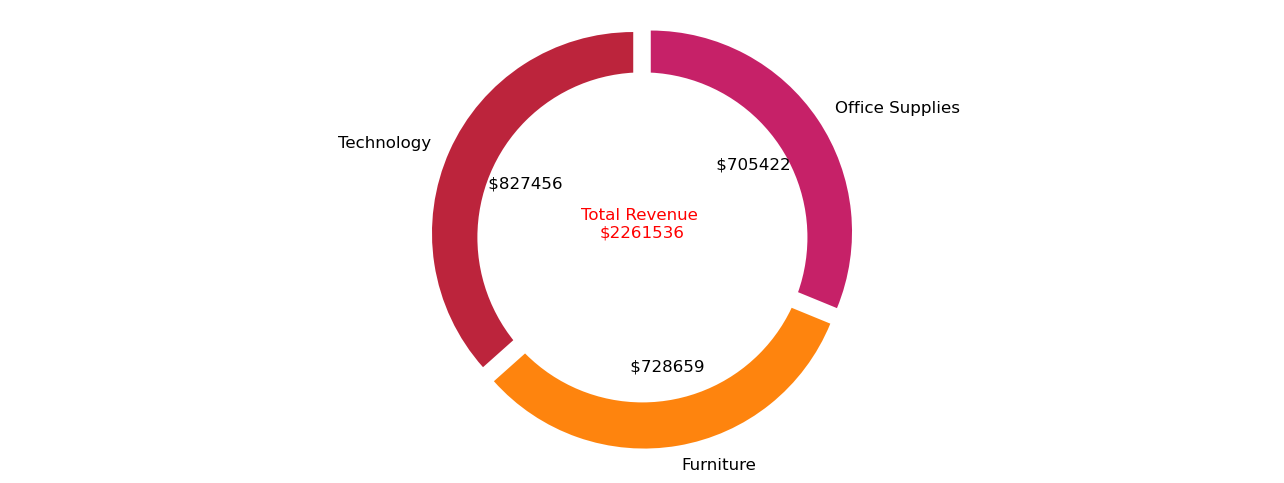

In [59]:
# pie chart for top 3 cat
plt.rcParams["figure.figsize"] = (13,5) # width and height of figure is defined in inches
plt.rcParams['font.size'] = 12.0 # Font size is defined
plt.rcParams['font.weight'] = 6 # Font weight is defined
# we don't want to look at the percentage distribution in the pie chart. Instead, we want to look at the exact revenue generated by the categories.
def autopct_format(values): 
    def my_format(pct): 
        total = sum(values) 
        val = int(round(pct*total/100.0))
        return ' ${v:d}'.format(v=val)
    return my_format
colors = ['#BC243C','#FE840E','#C62168'] # Colors are defined for the pie chart
explode = (0.05,0.05,0.05)
fig1, ax1 = plt.subplots()
ax1.pie(Top_category['Sales'], colors = colors, labels=Top_category['Category'], autopct= autopct_format(Top_category['Sales']), startangle=90,explode=explode)
centre_circle = plt.Circle((0,0),0.82,fc='white') # drawing a circle on the pie chart to make it look better 
fig = plt.gcf()
fig.gca().add_artist(centre_circle) # Add the circle on the pie chart
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal') 
# we can look the total revenue generated by all the categories at the center
label = ax1.annotate('Total Revenue \n'+str(total_revenue_category),color = 'red', xy=(0, 0), fontsize=12, ha="center")
plt.tight_layout()
plt.show()

In [60]:
# Sort both category and sub-category as per sales
Top_subcat = df.groupby(["Category", "Sub-Category"])["Sales"].sum().reset_index()
Top_subcat = Top_subcat.sort_values("Sales", ascending=False).head(10)  # Sort and get top 10

# Cast Sales column to integer data type
Top_subcat["Sales"] = Top_subcat["Sales"].astype(int)

# Sort values by Category
Top_subcat = Top_subcat.sort_values("Category")

# Reset index
Top_subcat.reset_index(drop=True, inplace=True)

# Calculate the total sales of all categories
Top_subcat_1 = Top_subcat.groupby("Category")["Sales"].sum().reset_index()

# Display the processed dataframe
print(Top_subcat)
print(Top_subcat_1)


          Category Sub-Category   Sales
0        Furniture       Chairs  322822
1        Furniture       Tables  202810
2        Furniture    Bookcases  113813
3  Office Supplies      Storage  219343
4  Office Supplies      Binders  200028
5  Office Supplies   Appliances  104618
6       Technology       Phones  327782
7       Technology     Machines  189238
8       Technology  Accessories  164186
9       Technology      Copiers  146248
          Category   Sales
0        Furniture  639445
1  Office Supplies  523989
2       Technology  827454


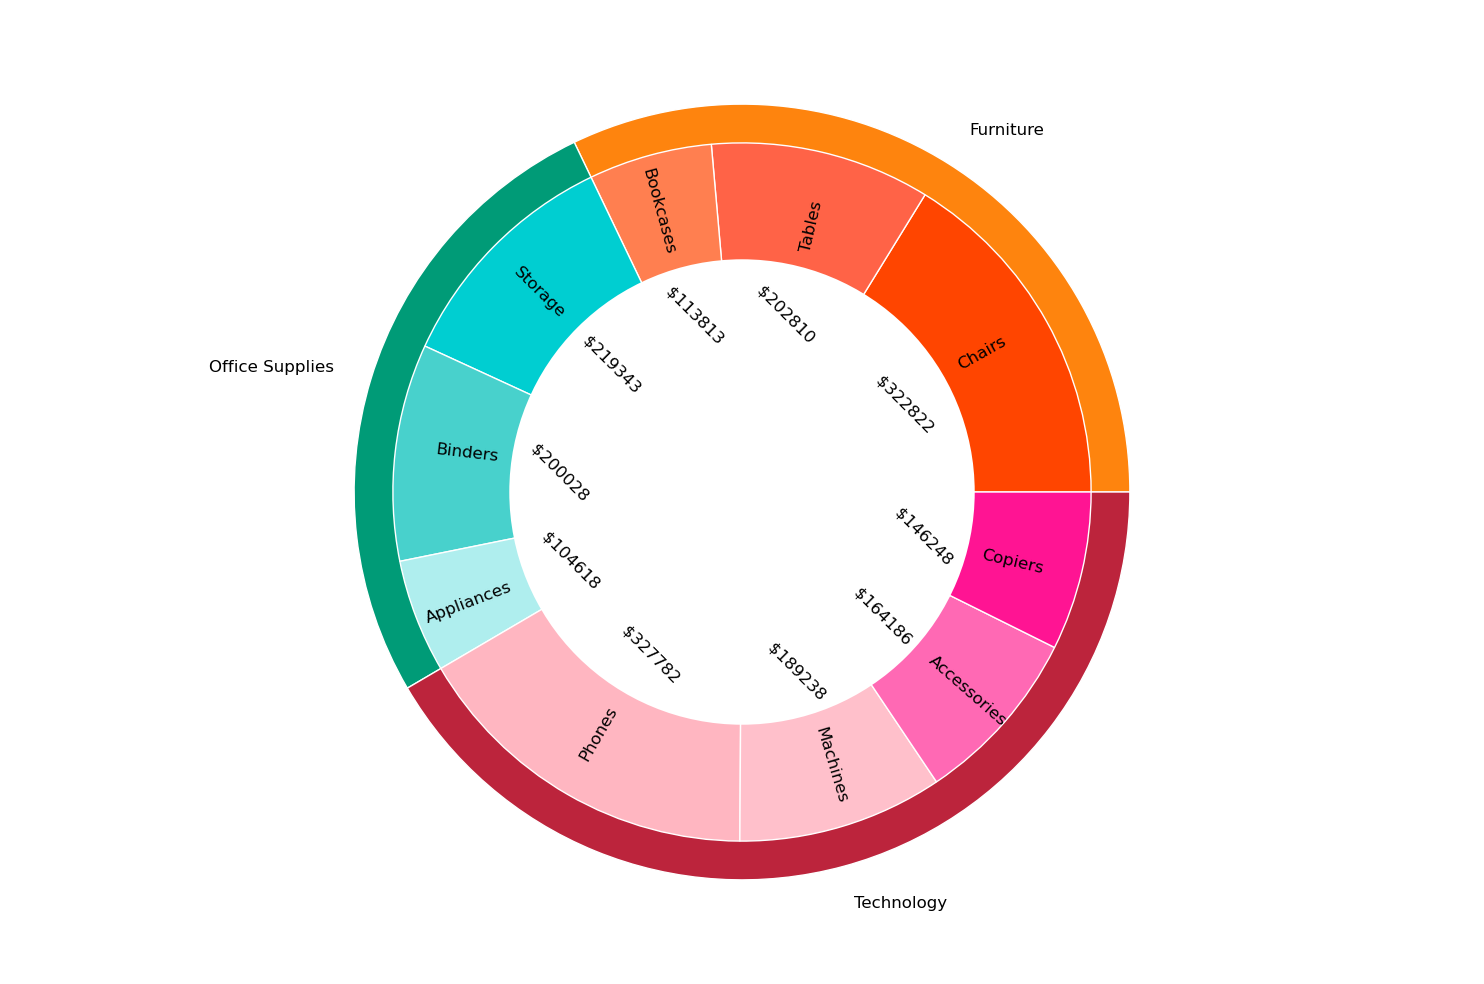

In [61]:
plt.rcParams["figure.figsize"] = (15,10) # width and height of figure is defined in inches
fig, ax = plt.subplots()
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle
width = 0.1
outer_colors = ['#FE840E','#009B77','#BC243C'] # Outer colors of the pie chart
inner_colors = ['Orangered','tomato','coral',"darkturquoise","mediumturquoise","paleturquoise","lightpink","pink","hotpink","deeppink"] # inner colors of the pie chart
pie = ax.pie(Top_subcat_1['Sales'], radius=1, labels=Top_subcat_1['Category'],colors=outer_colors,wedgeprops=dict(edgecolor='w'))
pie2 = ax.pie(Top_subcat['Sales'], radius=1-width, labels=Top_subcat['Sub-Category'],autopct= autopct_format(Top_subcat['Sales']),labeldistance=0.7,colors=inner_colors,wedgeprops=dict(edgecolor='w'), pctdistance=0.53,rotatelabels =True)
# Rotate fractions
# [0] = wedges, [1] = labels, [2] = fractions
fraction_text_list = pie2[2]
for text in fraction_text_list: 
    text.set_rotation(315) # rotate the autopct values
centre_circle = plt.Circle((0,0),0.6,fc='white') # Draw a circle on the pie chart
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')  
plt.tight_layout()
plt.show()


In [62]:
import pandas as pd
import plotly.graph_objects as go

# Sample df (assuming you have already loaded your sales data)
# df = pd.read_csv("your_data.csv") 

# Define state and state_code lists
state = ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 
         'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 
         'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 
         'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 
         'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 
         'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

state_code = ['AL','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA','KS','KY','LA','ME','MD','MA',
              'MI','MN','MS','MO','MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD',
              'TN','TX','UT','VT','VA','WA','WV','WI','WY']

# Create a DataFrame for states and their codes
state_df = pd.DataFrame({'State Code': state_code, 'State': state})

# Ensure numeric columns are summed
# Load or define the DataFrame `df` (replace 'your_data.csv' with your actual file path)
df = pd.read_csv('your_data.csv')
numeric_columns = df.select_dtypes(include=['number']).columns
sales = df.groupby("State")[numeric_columns].sum().sort_values("Sales", ascending=False)

# Reset index to make "State" a column
sales.reset_index(inplace=True)

# Drop "Postal Code" safely using axis=1
if 'Postal Code' in sales.columns:
    sales.drop('Postal Code', axis=1, inplace=True)

# Sort by "State"
sales = sales.sort_values('State', ascending=True).reset_index(drop=True)

# Merge sales with state codes
sales = sales.merge(state_df, on="State", how="left")

# Add text labels
sales['text'] = sales['State'] + '<br>Sales: ' + sales['Sales'].astype(str)

# Create the Choropleth map
fig = go.Figure(data=go.Choropleth(
    locations=sales['State Code'],  # Spatial coordinates
    text=sales['text'],
    z=sales['Sales'].astype(float),  # Data to be color-coded
    locationmode='USA-states',  # Set of locations match entries in `locations`
    colorscale='Blues',
    colorbar_title="Sales",
))

fig.update_layout(
    title_text='Sales',
    geo_scope='usa',  # Limit map scope to USA
)

fig.show()


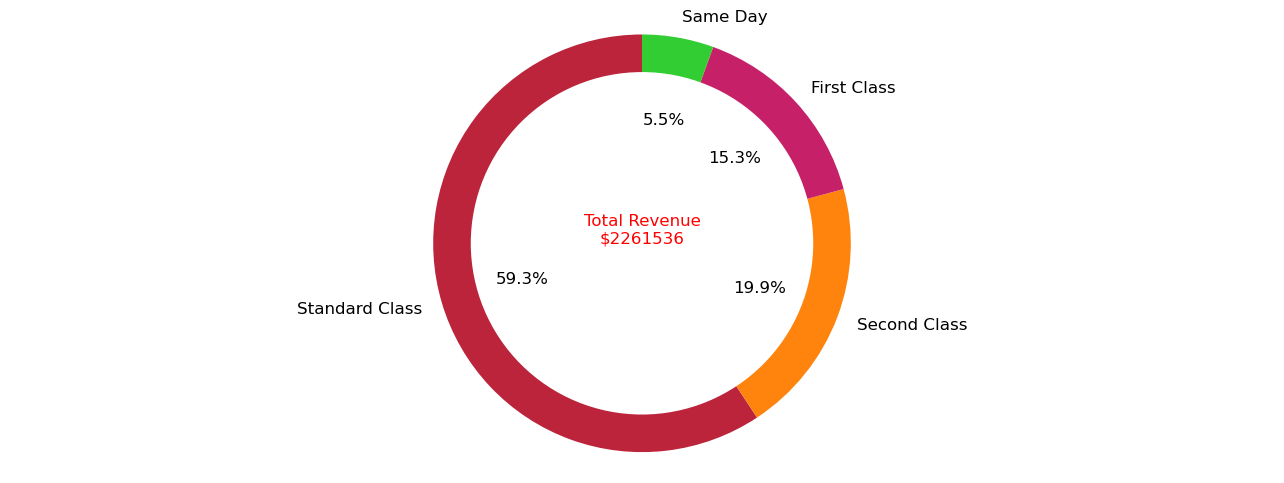

In [63]:
# Which shipping mode has the highest sales?
# Group by "Ship Mode" and sum only numeric columns
Top_shipping = df.groupby(["Ship Mode"]).sum(numeric_only=True).sort_values("Sales", ascending=False)

# Keep only the "Sales" column
Top_shipping = Top_shipping[["Sales"]]

# Reset index to add "Ship Mode" back as a column
Top_shipping.reset_index(inplace=True)

# Compute total revenue
total_revenue_ship = Top_shipping["Sales"].sum()
total_revenue_ship = f"${int(total_revenue_ship)}"  # Convert to integer and format as a string with "$"

# Pie Chart Configurations
plt.rcParams["figure.figsize"] = (13, 5)  # Define figure size
plt.rcParams['font.size'] = 12  # Font size
plt.rcParams['font.weight'] = 6  # Font weight
colors = ['#BC243C', '#FE840E', '#C62168', "limegreen"]  # Define pie chart colors

# Create pie chart
fig1, ax1 = plt.subplots()
ax1.pie(Top_shipping['Sales'], colors=colors, labels=Top_shipping['Ship Mode'], autopct='%1.1f%%', startangle=90)

# Add a center circle to create a donut chart effect
centre_circle = plt.Circle((0, 0), 0.82, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures the pie is drawn as a circle
ax1.axis('equal')

# Annotate total revenue at the center of the chart
ax1.annotate(f'Total Revenue\n{total_revenue_ship}', color='red', xy=(0, 0), fontsize=12, ha="center")

# Adjust layout and display chart
plt.tight_layout()
plt.show()

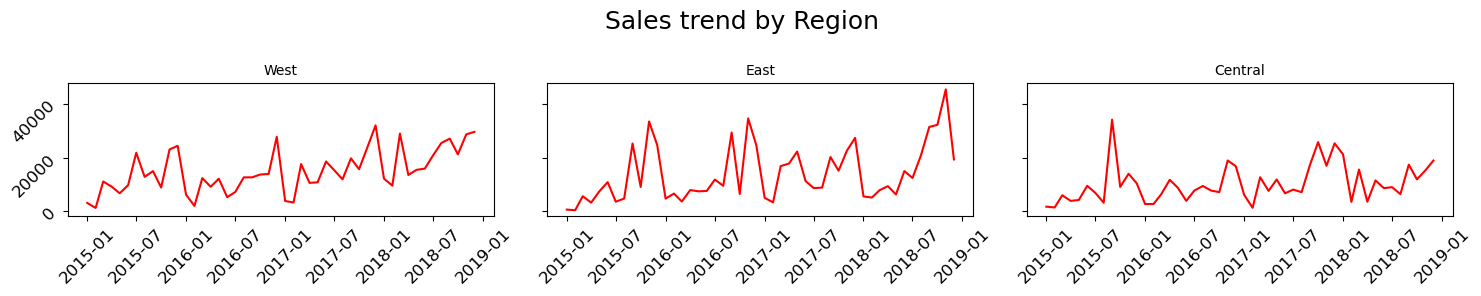

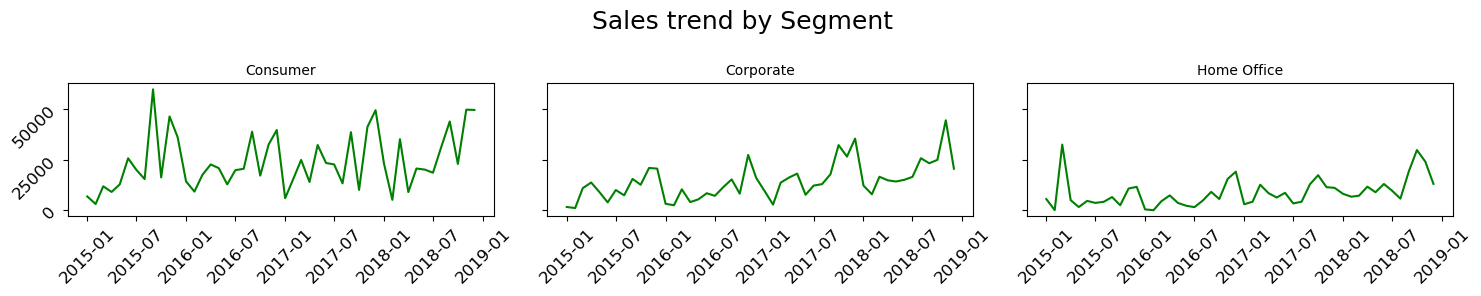

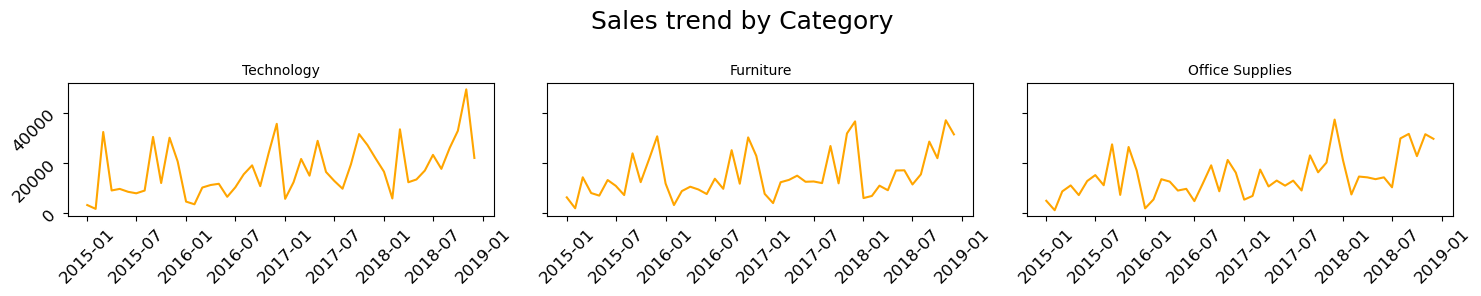

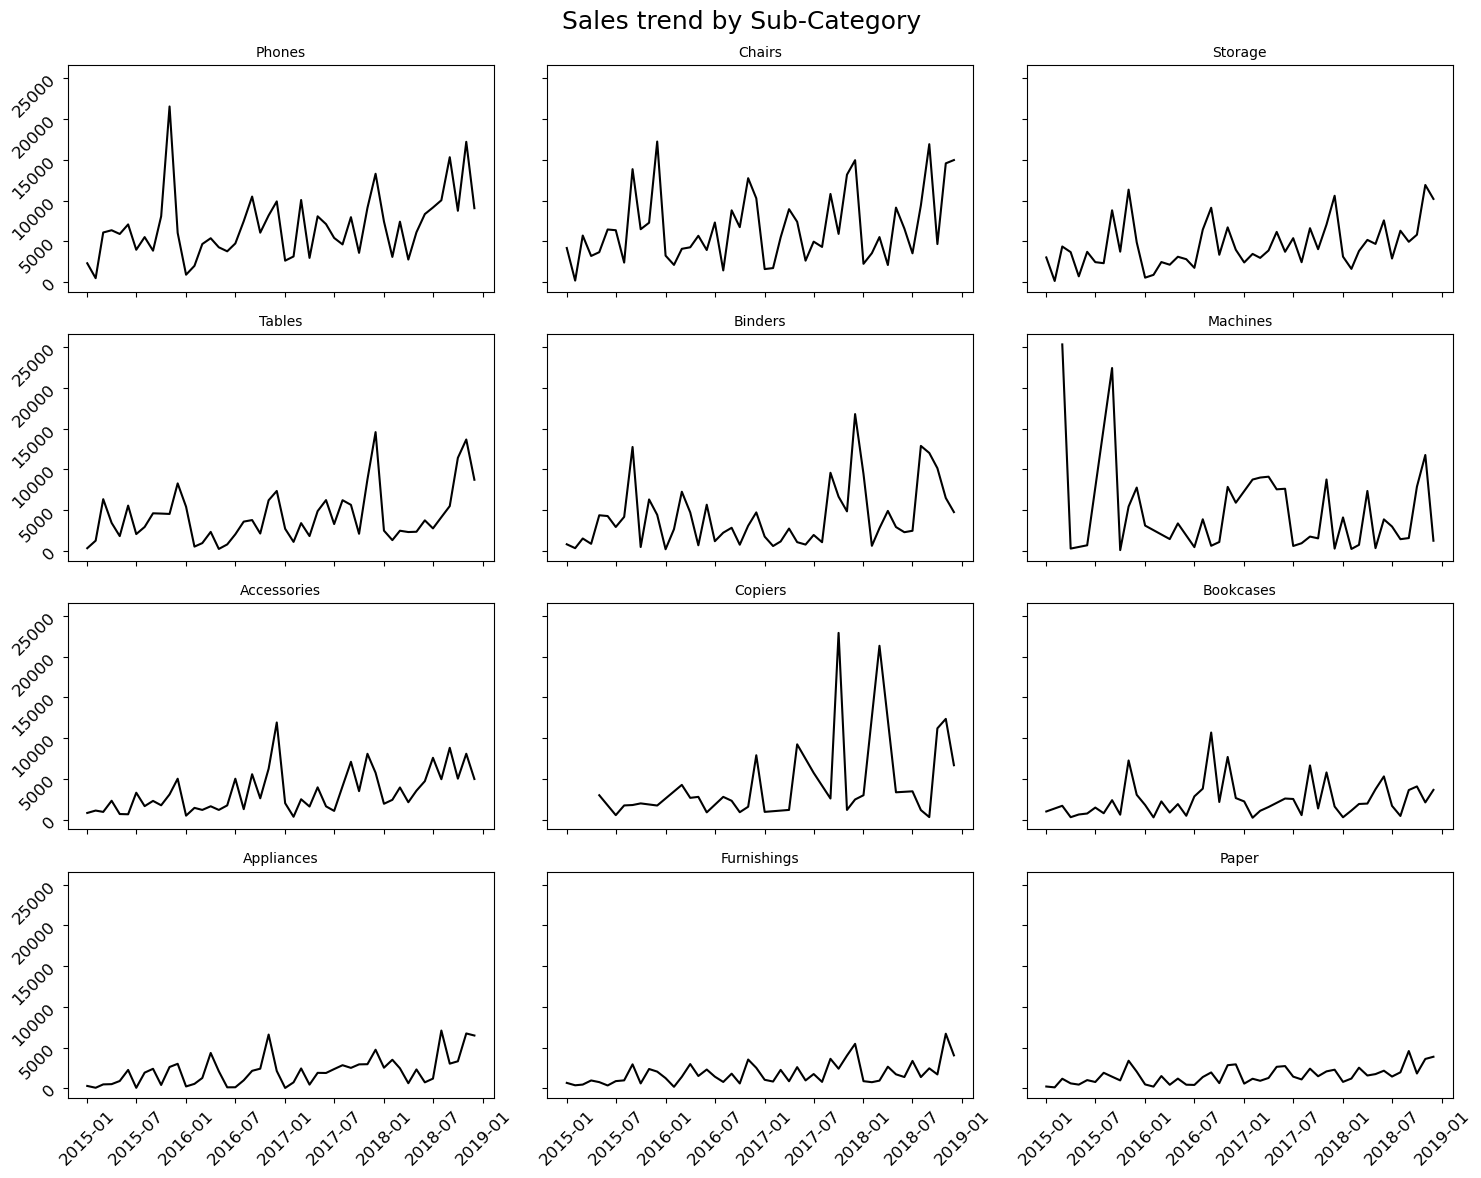

In [64]:
# this function is to plot trend per selected feature
def plot_trend_group(group,size, color='blue'):
    sales_by_group = df.groupby(group)['Sales'].sum() # group sales by group
    sales_by_group.sort_values(ascending= False, inplace=True) # sort values
    sales_by_group.head(size) # select top records
    # subplots with 3 plots per line
    fig, axes = plt.subplots(int(size/3),3, figsize=(15,size), sharex =True, sharey =True)
    fig.suptitle('Sales trend by {}'.format(group), fontsize=18)
    # loop over selected groups in a feature
    for ax,group_name in zip(axes.flat, sales_by_group.index):
        sales_group = df[df[group]==group_name]
        sales_group = sales_group.groupby("Month_order")['Sales'].sum()
        sales_group.index = sales_group.index.to_timestamp()
        ax.tick_params(labelrotation=45)
        ax.set_title(group_name, fontsize = 10)
        ax.plot(sales_group, color=color)
    fig.tight_layout()
plot_trend_group('Region',3, 'red') # trend per region
plot_trend_group('Segment',3,'green') # trend per segment
plot_trend_group('Category',3, 'orange') # trend per Category
plot_trend_group('Sub-Category',12, 'black') # trend per Sub-Category


In [65]:
monthly_sales = df.groupby("Month_order")['Sales'].sum()
monthly_sales = pd.DataFrame(monthly_sales)
monthly_sales['time'] = np.arange(len(monthly_sales.index))
monthly_sales.head()

,Sales,time
Month_order,,
2015-01,14205.707,0
2015-02,4519.892,1
2015-03,55205.797,2
2015-04,27906.855,3
2015-05,23644.303,4


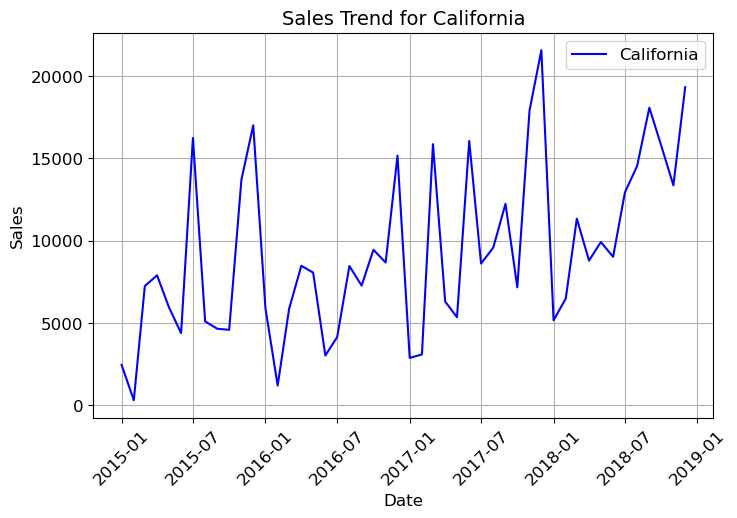

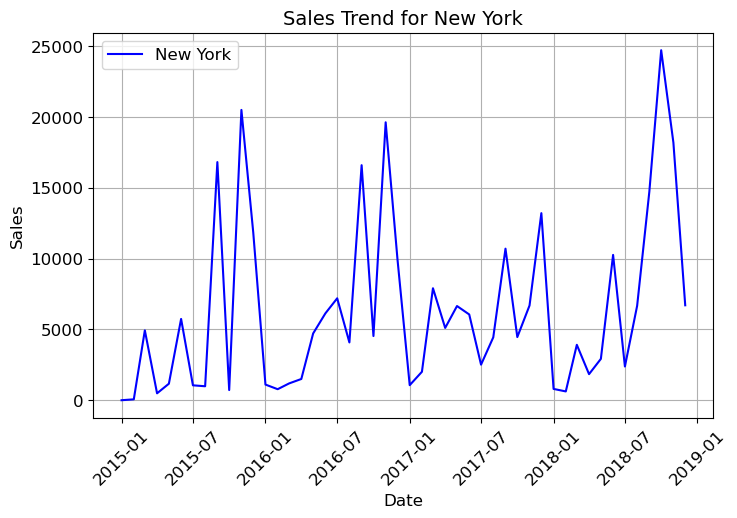

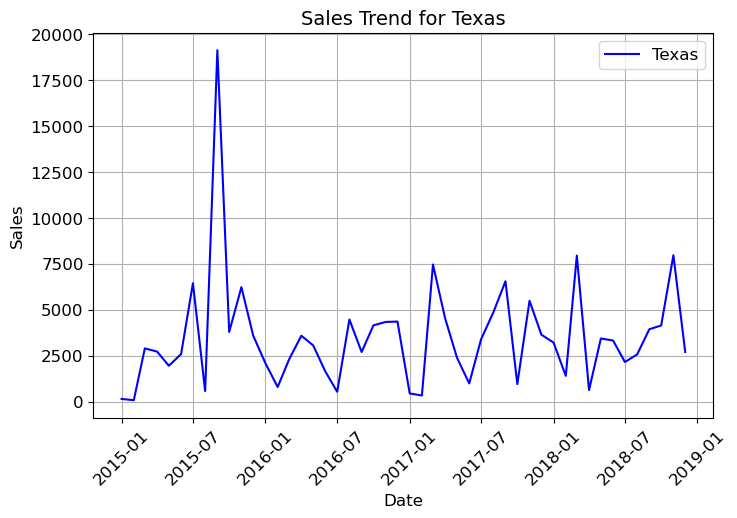

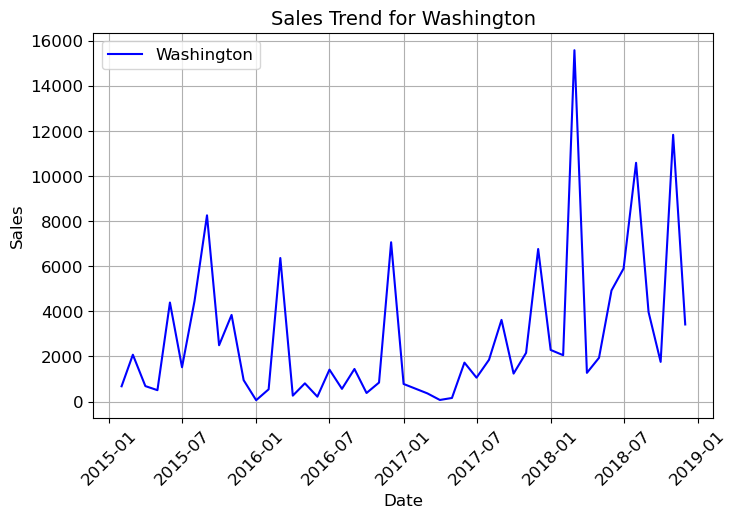

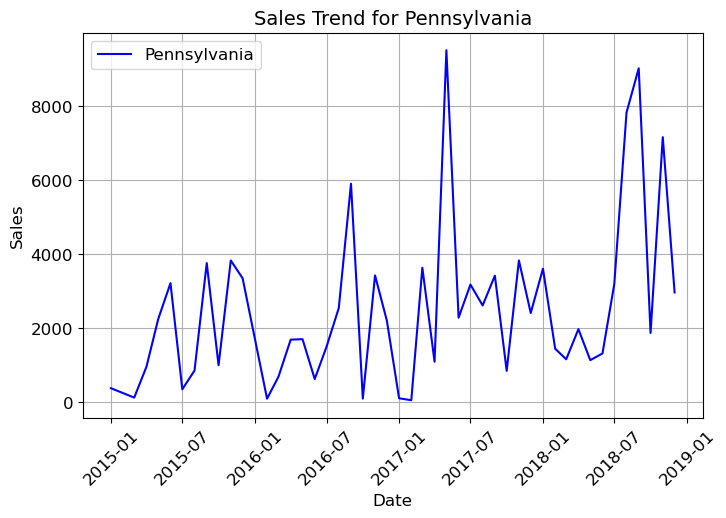

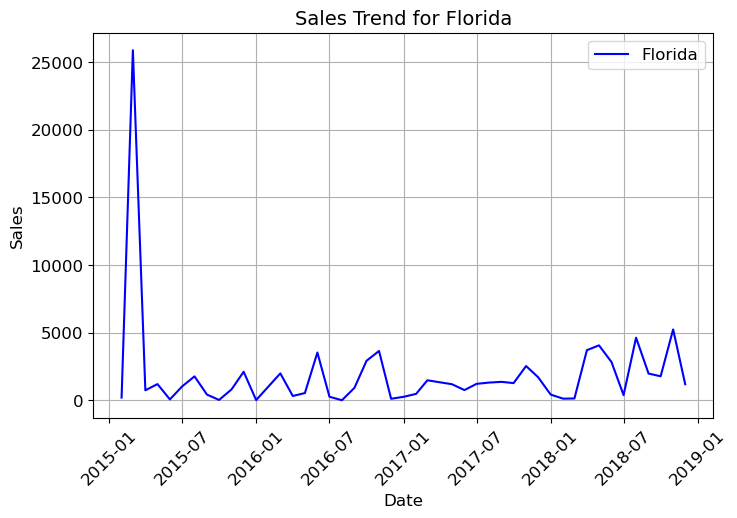

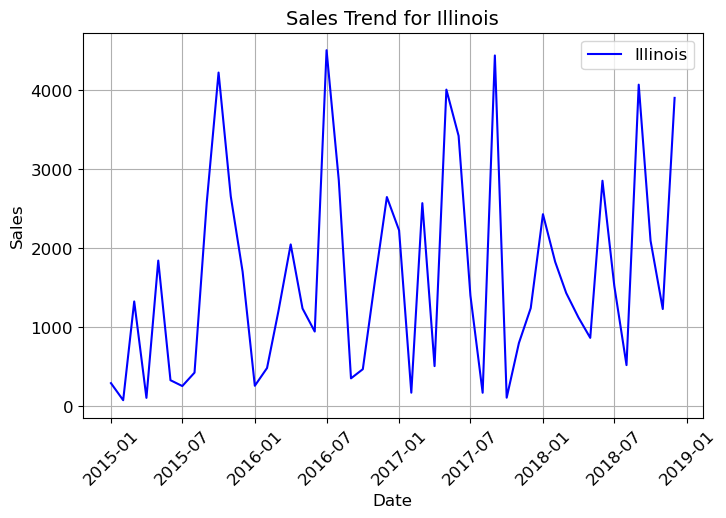

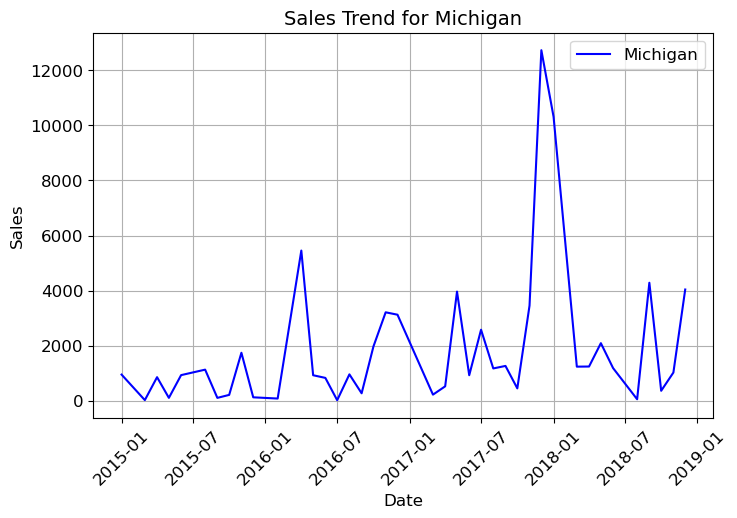

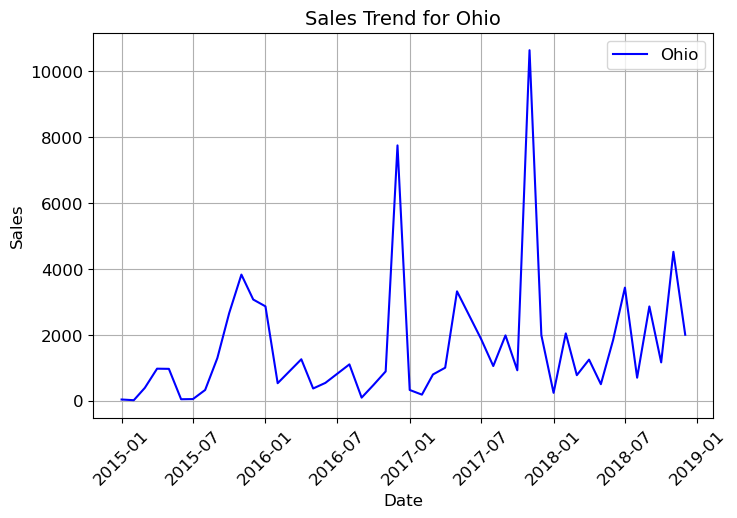

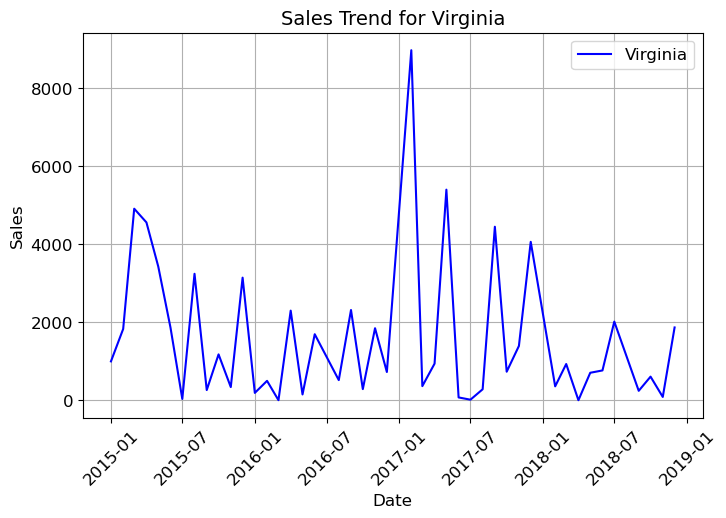

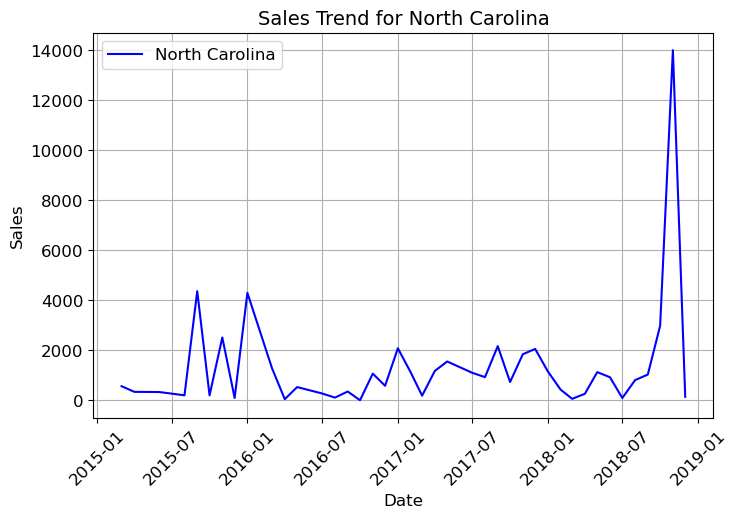

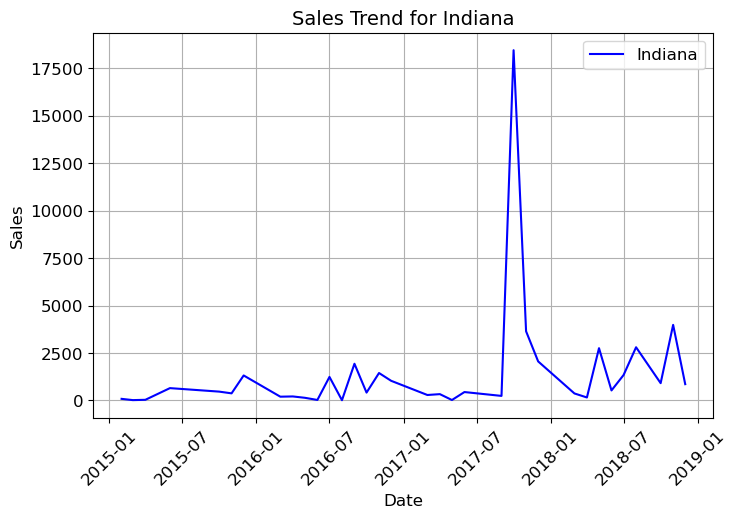

In [66]:
def plot_trend_per_state(size=12, color='blue'):
    sales_by_state = df.groupby('State')['Sales'].sum()  # Group sales by state
    sales_by_state.sort_values(ascending=False, inplace=True)  # Sort by sales
    top_states = sales_by_state.head(size).index  # Get the top 'size' states

    # Loop over each state and create separate plots
    for state in top_states:
        state_sales = df[df['State'] == state]
        state_sales = state_sales.groupby("Month_order")['Sales'].sum()  # Group by month
        state_sales.index = state_sales.index.to_timestamp()  # Convert to datetime
        
        plt.figure(figsize=(8, 5))  # Create a new figure for each state
        plt.plot(state_sales, color=color, label=state)
        plt.title(f'Sales Trend for {state}', fontsize=14)
        plt.xlabel('Date')
        plt.ylabel('Sales')
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True)

        # Show the plot (or save it if needed)
        plt.show()
        # plt.savefig(f"sales_trend_{state}.png")  # Uncomment to save each plot

# Call function to generate separate graphs for each state
plot_trend_per_state()
